# Ejecución de la Tarea 1

Este notebook ejecuta los experimentos correspondientes a los cuatro
problemas de la tarea y genera las tablas y figuras utilizadas en el informe.

## Configuración

In [1]:
import os
import sys
from pathlib import Path

import matplotlib
import numpy as np
import pandas as pd


def encontrar_raiz_repositorio() -> Path:
    """Busca la carpeta que contiene el directorio ``tarea1``."""
    candidatos = [Path.cwd(), *Path.cwd().parents]
    if "__file__" in globals():
        archivo = Path(__file__).resolve()
        candidatos = [archivo.parent, *archivo.parents, *candidatos]

    for candidato in candidatos:
        if (candidato / "tarea1" / "src").is_dir():
            return candidato

    raise RuntimeError(
        "No se encontró la raíz de Control_Optimo_Machine_Learning. "
        "Ejecute el notebook dentro del repositorio."
    )


RAIZ_REPOSITORIO = encontrar_raiz_repositorio()
RUTA_TAREA1 = RAIZ_REPOSITORIO / "tarea1"
RUTA_SRC = RUTA_TAREA1 / "src"

for ruta in (RUTA_TAREA1, RUTA_SRC):
    ruta_str = str(ruta)
    if ruta_str not in sys.path:
        sys.path.insert(0, ruta_str)

if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")

import matplotlib.pyplot as plt

from src.integradores import EDOSolver
from src.problemas_control import ConjuntoAdmisible, ControlProblem
from src.reporte_problema3 import generar_reporte_problema3
from src.reporte_problema4 import generar_reporte_problema4
from src.validacion_problema1 import (
    campo_lotka_volterra,
    campo_van_der_pol,
    crear_referencia,
    ejecutar_experimento,
)
from src.validacion_problema3 import crear_problema_lqr_fbsm
from utils.visualizacion import (
    graficar_diagrama_fase,
    graficar_error_vs_h,
    graficar_referencia_vs_aproximada,
    tabla_resultados,
)

RUTA_RESULTADOS = RUTA_TAREA1 / "resultados_graficos"
RUTA_BASE = RUTA_RESULTADOS
RUTA_LOTKA = RUTA_RESULTADOS / "1_lotka_volterra"
RUTA_VDP = RUTA_RESULTADOS / "1_van_der_pol"
RUTA_PROBLEMA3 = RUTA_RESULTADOS / "3_fbsm"
RUTA_PROBLEMA4 = RUTA_BASE / "4_gradiente_proyectado"

for ruta in (RUTA_LOTKA, RUTA_VDP, RUTA_PROBLEMA3, RUTA_PROBLEMA4):
    ruta.mkdir(parents=True, exist_ok=True)

MODO_RAPIDO = os.getenv("TAREA1_REPORTE_RAPIDO") == "1"

print(f"Raíz del repositorio: {RAIZ_REPOSITORIO}")
print(f"Modo rápido: {MODO_RAPIDO}")

Raíz del repositorio: /Users/tomy/ProyectosNvim/Control_Optimo_Machine_Learning
Modo rápido: False


In [2]:
def mostrar_figuras(figuras) -> None:
    """Muestra las figuras."""
    for figura in figuras:
        figura.show()


def mostrar_tabla(tabla: pd.DataFrame) -> None:
    """Muestra una tabla."""
    print(tabla.to_string(index=False))

# Problema 1: integrador numérico de EDO

## Problema 1(a): interfaz de `EDOSolver` y `EDOSolution`

Se integra el problema escalar $\dot{x}=-x$, $x(0)=1$, mediante los cinco
esquemas implementados. La solución exacta en $t=1$ es $e^{-1}$.

In [3]:
solver = EDOSolver()
metodos = [
    "euler_progresivo",
    "euler_implicito",
    "heun",
    "crank_nicolson",
    "rk4",
]

filas_interfaz = []
for metodo in metodos:
    solucion = solver.solve(
        lambda t, x, u: -x,
        np.array([1.0]),
        (0.0, 1.0),
        0.1,
        method=metodo,
        guardar_intermedios=(metodo == "rk4"),
    )
    filas_interfaz.append(
        {
            "método": metodo,
            "nodos": len(solucion.tiempos),
            "x(1)": solucion.estados[-1, 0],
            "error final": abs(solucion.estados[-1, 0] - np.exp(-1.0)),
        }
    )

tabla_interfaz = pd.DataFrame(filas_interfaz)
tabla_interfaz

,método,nodos,x(1),error final
0,euler_progresivo,11,0.348678,1.920100e-02
1,euler_implicito,11,0.385543,1.766385e-02
2,heun,11,0.368541,6.615437e-04
3,crank_nicolson,11,0.367573,3.068988e-04
4,rk4,11,0.367880,3.332411e-07


In [4]:
print("Tipo de solución:", type(solucion).__name__)
print("Intervalo:", solucion.t_span)
print("Forma de los estados:", solucion.estados.shape)
print("Etapas intermedias disponibles:", solucion.intermedios is not None)

Tipo de solución: EDOSolution
Intervalo: (0.0, 1.0)
Forma de los estados: (11, 1)
Etapas intermedias disponibles: True


## Problema 1(b)(i): sistema de Lotka--Volterra

Se utilizan los parámetros establecidos en el enunciado:
$\alpha=1.1$, $\beta=0.4$, $\delta=0.1$, $\gamma=0.4$,
con $(x(0),y(0))=(10,5)$.

In [5]:
parametros_lotka = {
    "alpha": 1.1,
    "beta": 0.4,
    "delta": 0.1,
    "gamma": 0.4,
}
x0_lotka = np.array([10.0, 5.0])
t0_lotka, tf_lotka = 0.0, 15.0
hs_lotka = [0.1, 0.05, 0.025, 0.0125, 0.00625]

resultados_lotka = ejecutar_experimento(
    campo_lotka_volterra,
    x0_lotka,
    t0_lotka,
    tf_lotka,
    parametros_lotka,
    hs_lotka,
    metodos,
)

tabla_lotka = tabla_resultados(resultados_lotka)
tabla_lotka

/Users/tomy/ProyectosNvim/Control_Optimo_Machine_Learning/tarea1/src/integradores.py:296: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  return fsolve(residual, x0=guess_inicial, **argumentos_fsolve)


,metodo,h,error_inf,tiempo_s
0,euler_progresivo,0.10000,5.606148e+00,0.001381
1,euler_progresivo,0.05000,2.442348e+00,0.002723
2,euler_progresivo,0.02500,1.135678e+00,0.003440
3,euler_progresivo,0.01250,5.475414e-01,0.007715
4,euler_progresivo,0.00625,2.688424e-01,0.013132
5,euler_implicito,0.10000,3.189306e+00,0.017510
6,euler_implicito,0.05000,1.831104e+00,0.031057
7,euler_implicito,0.02500,9.827476e-01,0.066214
8,euler_implicito,0.01250,5.093065e-01,0.112400
9,euler_implicito,0.00625,2.592837e-01,0.217445


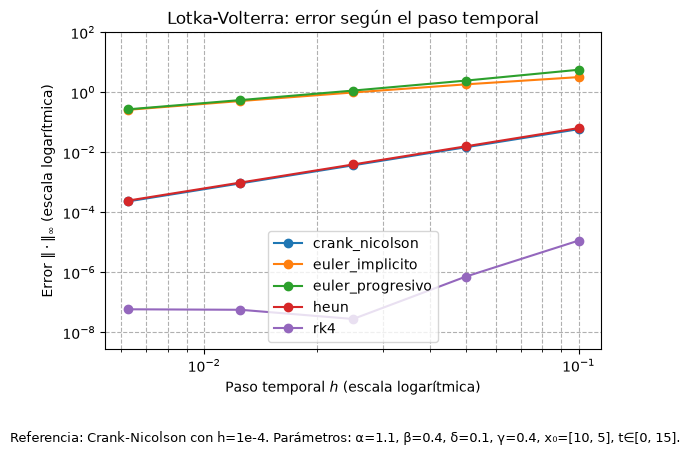

In [6]:
caption_error_lotka = (
    "Referencia: Crank-Nicolson con h=1e-4. "
    "Parámetros: α=1.1, β=0.4, δ=0.1, γ=0.4, "
    "x₀=[10, 5], t∈[0, 15]."
)
fig_error_lotka = graficar_error_vs_h(
    resultados_lotka,
    ruta_salida=RUTA_LOTKA / "error_vs_h.png",
    titulo="Lotka-Volterra: error según el paso temporal",
    metodo_referencia="Crank-Nicolson",
    h_referencia=1e-4,
    caption=caption_error_lotka,
)

/Users/tomy/ProyectosNvim/Control_Optimo_Machine_Learning/tarea1/src/integradores.py:296: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  return fsolve(residual, x0=guess_inicial, **argumentos_fsolve)


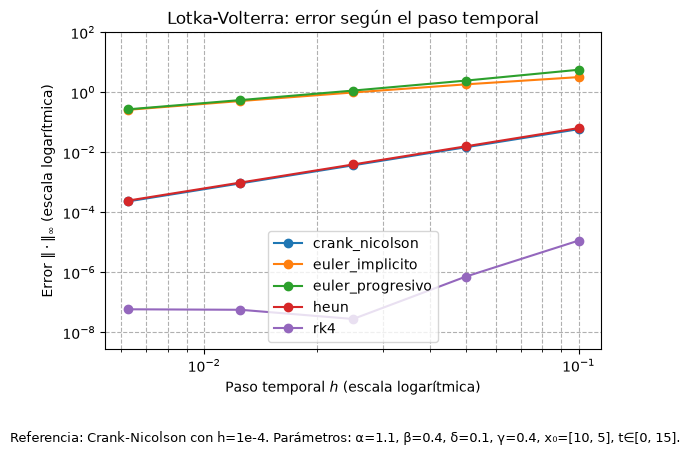

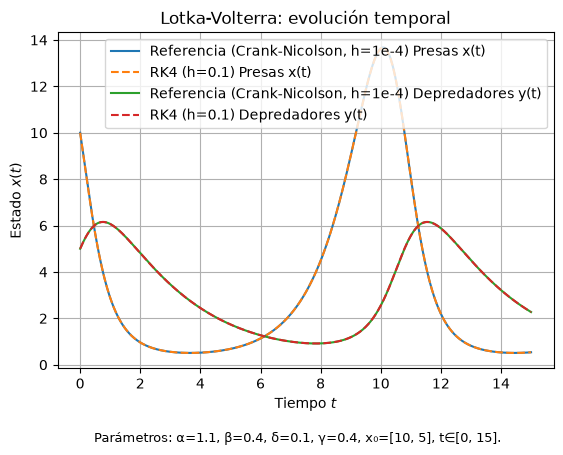

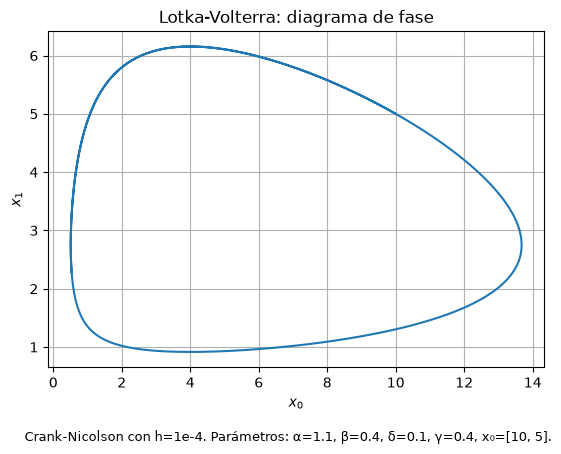

In [7]:
t_ref_lotka, sol_ref_lotka = crear_referencia(
    campo_lotka_volterra,
    x0_lotka,
    t0_lotka,
    tf_lotka,
    parametros_lotka,
    h=1e-4,
    metodo="crank_nicolson",
)

solucion_lotka_rk4 = solver.solve(
    lambda t, x, u: campo_lotka_volterra(t, x, u, parametros_lotka),
    x0_lotka,
    (t0_lotka, tf_lotka),
    0.1,
    method="rk4",
)

fig_series_lotka = graficar_referencia_vs_aproximada(
    t_ref_lotka,
    sol_ref_lotka.estados,
    solucion_lotka_rk4.tiempos,
    solucion_lotka_rk4.estados,
    "Lotka-Volterra: evolución temporal",
    ruta_salida=RUTA_LOTKA / "series_temporales.png",
    nombres_componentes=["Presas x(t)", "Depredadores y(t)"],
    descripcion_referencia="Referencia (Crank-Nicolson, h=1e-4)",
    descripcion_aproximacion="RK4 (h=0.1)",
    caption=(
        "Parámetros: α=1.1, β=0.4, δ=0.1, γ=0.4, "
        "x₀=[10, 5], t∈[0, 15]."
    ),
)

fig_fase_lotka = graficar_diagrama_fase(
    sol_ref_lotka.estados,
    "Lotka-Volterra: diagrama de fase",
    ruta_salida=RUTA_LOTKA / "diagrama_fase.png",
    caption=(
        "Crank-Nicolson con h=1e-4. "
        "Parámetros: α=1.1, β=0.4, δ=0.1, γ=0.4, x₀=[10, 5]."
    ),
)

mostrar_figuras([fig_error_lotka, fig_series_lotka, fig_fase_lotka])

## Problema 1(b)(ii): oscilador de Van der Pol con $\mu=1000$

Se comparan métodos explícitos e implícitos mediante el error respecto de una
referencia Crank--Nicolson y el tiempo de ejecución.

In [8]:
parametros_vdp = {"mu": 1000.0}
x0_vdp = np.array([2.0, 0.0])
t0_vdp, tf_vdp = 0.0, 10.0
h_referencia_vdp = 1e-5 if not MODO_RAPIDO else 1e-4

print("Calculando la referencia de Van der Pol...")
_, solucion_ref_vdp = crear_referencia(
    campo_van_der_pol,
    x0_vdp,
    t0_vdp,
    tf_vdp,
    parametros_vdp,
    h=h_referencia_vdp,
    metodo="crank_nicolson",
)

hs_explicitos_grandes = [1e-2, 5e-3, 2.5e-3, 1.25e-3]
hs_implicitos = [0.1, 0.05, 0.025, 0.0125, 0.00625]
hs_explicitos_pequenos = [1e-5, 5e-6] if not MODO_RAPIDO else [1e-4, 5e-5]

resultados_vdp_explicitos = ejecutar_experimento(
    campo_van_der_pol,
    x0_vdp,
    t0_vdp,
    tf_vdp,
    parametros_vdp,
    hs_explicitos_grandes,
    ["euler_progresivo", "heun", "rk4"],
    h_referencia=h_referencia_vdp,
    solucion_ref=solucion_ref_vdp,
)

resultados_vdp_implicitos = ejecutar_experimento(
    campo_van_der_pol,
    x0_vdp,
    t0_vdp,
    tf_vdp,
    parametros_vdp,
    hs_implicitos,
    ["euler_implicito", "crank_nicolson"],
    h_referencia=h_referencia_vdp,
    solucion_ref=solucion_ref_vdp,
)

resultados_vdp_paso_pequeno = ejecutar_experimento(
    campo_van_der_pol,
    x0_vdp,
    t0_vdp,
    tf_vdp,
    parametros_vdp,
    hs_explicitos_pequenos,
    ["euler_progresivo", "rk4"],
    h_referencia=h_referencia_vdp,
    solucion_ref=solucion_ref_vdp,
)

resultados_vdp = (
    resultados_vdp_explicitos
    + resultados_vdp_implicitos
    + resultados_vdp_paso_pequeno
)

tabla_vdp = tabla_resultados(resultados_vdp)
tabla_vdp

Calculando la referencia de Van der Pol...


/Users/tomy/ProyectosNvim/Control_Optimo_Machine_Learning/tarea1/src/validacion_problema1.py:138: RuntimeWarning: overflow encountered in scalar multiply
  dx1 = mu * (1.0 - x[0] ** 2) * x[1] - x[0]
/Users/tomy/ProyectosNvim/Control_Optimo_Machine_Learning/tarea1/src/validacion_problema1.py:138: RuntimeWarning: overflow encountered in scalar power
  dx1 = mu * (1.0 - x[0] ** 2) * x[1] - x[0]
/Users/tomy/ProyectosNvim/Control_Optimo_Machine_Learning/tarea1/src/integradores.py:280: RuntimeWarning: invalid value encountered in add
  estados[k + 1] = x_k + pasos[k] * np.asarray(pendiente)


/Users/tomy/ProyectosNvim/Control_Optimo_Machine_Learning/tarea1/src/integradores.py:414: RuntimeWarning: invalid value encountered in add
  pendiente_inicial + pendiente_predictor


/Users/tomy/ProyectosNvim/Control_Optimo_Machine_Learning/tarea1/src/validacion_problema1.py:138: RuntimeWarning: invalid value encountered in scalar subtract
  dx1 = mu * (1.0 - x[0] ** 2) * x[1] - x[0]
/Users/tomy/ProyectosNvim/Control_Optimo_Machine_Learning/tarea1/src/integradores.py:458: RuntimeWarning: invalid value encountered in add
  k1 + 2.0 * k2 + 2.0 * k3 + k4


,metodo,h,error_inf,tiempo_s
0,euler_progresivo,0.010000,NaN,0.028012
1,euler_progresivo,0.005000,NaN,0.028743
2,euler_progresivo,0.002500,NaN,0.041698
3,euler_progresivo,0.001250,NaN,0.072819
4,heun,0.010000,NaN,0.016760
5,heun,0.005000,NaN,0.036845
6,heun,0.002500,NaN,0.244902
7,heun,0.001250,NaN,0.173541
8,rk4,0.010000,NaN,0.043794
9,rk4,0.005000,NaN,0.151462


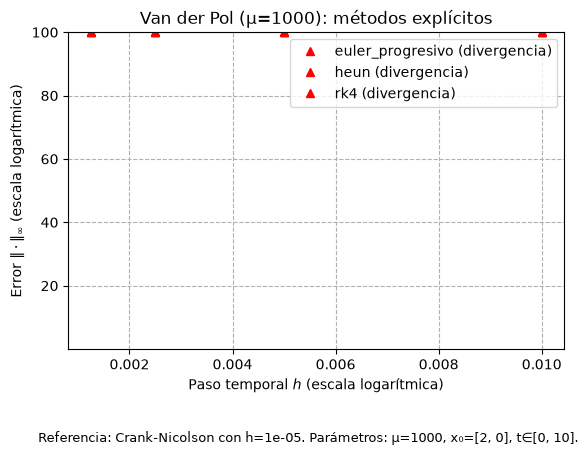

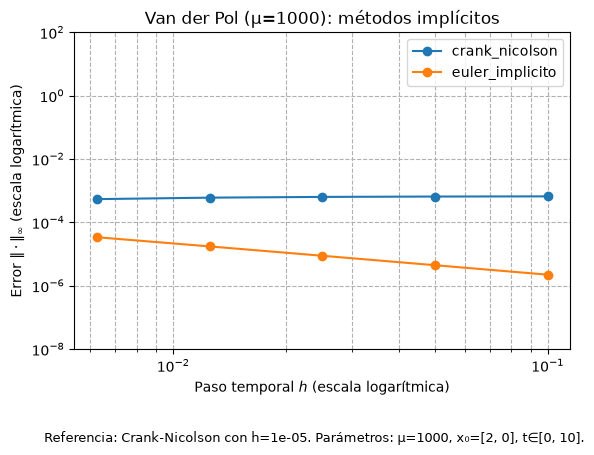

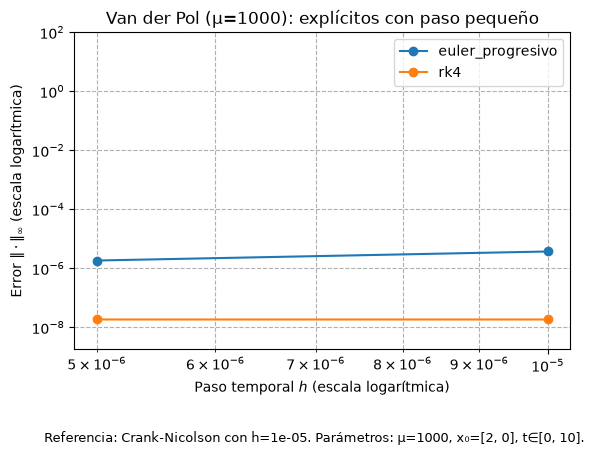

In [9]:
caption_vdp = (
    f"Referencia: Crank-Nicolson con h={h_referencia_vdp:g}. "
    "Parámetros: μ=1000, x₀=[2, 0], t∈[0, 10]."
)

fig_vdp_explicitos = graficar_error_vs_h(
    resultados_vdp_explicitos,
    ruta_salida=RUTA_VDP / "error_vs_h_mu_1000_explicitos_pasos_grandes.png",
    titulo="Van der Pol (μ=1000): métodos explícitos",
    metodo_referencia="Crank-Nicolson",
    h_referencia=h_referencia_vdp,
    caption=caption_vdp,
)

fig_vdp_implicitos = graficar_error_vs_h(
    resultados_vdp_implicitos,
    ruta_salida=RUTA_VDP / "error_vs_h_mu_1000_implicitos_pasos_grandes.png",
    titulo="Van der Pol (μ=1000): métodos implícitos",
    metodo_referencia="Crank-Nicolson",
    h_referencia=h_referencia_vdp,
    caption=caption_vdp,
)

fig_vdp_pequenos = graficar_error_vs_h(
    resultados_vdp_paso_pequeno,
    ruta_salida=RUTA_VDP / "error_vs_h_mu_1000_explicitos_pasos_pequenos.png",
    titulo="Van der Pol (μ=1000): explícitos con paso pequeño",
    metodo_referencia="Crank-Nicolson",
    h_referencia=h_referencia_vdp,
    caption=caption_vdp,
)

mostrar_figuras([fig_vdp_explicitos, fig_vdp_implicitos, fig_vdp_pequenos])

# Problema 2: clase para problemas de control óptimo

Se construye un problema escalar de tipo Bolza y se muestran las
funcionalidades solicitadas: evaluación del costo, Hamiltoniano, sistema
adjunto, condición de transversalidad y minimización puntual.

In [10]:
def crear_control_escalar(con_caja: bool) -> ControlProblem:
    conjunto = ConjuntoAdmisible(((-0.5, 0.5),)) if con_caja else None
    return ControlProblem(
        f=lambda t, x, u: np.array([-x[0] + u[0]]),
        l=lambda t, x, u: 0.5 * (x[0] ** 2 + u[0] ** 2),
        phi=lambda x: 0.5 * x[0] ** 2,
        df_dx=lambda t, x, u: np.array([[-1.0]]),
        df_du=lambda t, x, u: np.array([[1.0]]),
        dl_dx=lambda t, x, u: np.array([x[0]]),
        dl_du=lambda t, x, u: np.array([u[0]]),
        dphi_dx=lambda x: np.array([x[0]]),
        t_span=(0.0, 2.0),
        x0=np.array([1.0]),
        m=1,
        conjunto_admisible=conjunto,
    )


problema_irrestricto = crear_control_escalar(con_caja=False)
problema_caja = crear_control_escalar(con_caja=True)

h_control = 0.1
tiempos_control = np.linspace(0.0, 2.0, int(round(2.0 / h_control)) + 1)
control_nulo = np.zeros((tiempos_control.size, 1))

x_muestra = np.array([0.8])
p_muestra = np.array([0.3])
u_muestra = np.array([0.2])

resultados_control = pd.DataFrame(
    [
        {
            "cantidad": "J[u=0]",
            "valor": problema_irrestricto.evaluar_costo(
                control_nulo, h_control, "crank_nicolson"
            ),
        },
        {
            "cantidad": "H(t,x,p,u)",
            "valor": problema_irrestricto.hamiltoniano(
                0.5, x_muestra, p_muestra, u_muestra
            ),
        },
        {
            "cantidad": "sistema adjunto",
            "valor": problema_irrestricto.sistema_adjunto(
                0.5, x_muestra, p_muestra, u_muestra
            )[0],
        },
        {
            "cantidad": "transversalidad",
            "valor": problema_irrestricto.condicion_transversalidad(x_muestra)[0],
        },
        {
            "cantidad": "control puntual irrestricto",
            "valor": problema_irrestricto.control_optimo_puntual(
                0.5, x_muestra, p_muestra
            )[0],
        },
        {
            "cantidad": "control puntual con caja",
            "valor": problema_caja.control_optimo_puntual(
                0.5, x_muestra, np.array([2.0])
            )[0],
        },
    ]
)
resultados_control

,cantidad,valor
0,J[u=0],0.255177
1,"H(t,x,p,u)",0.160000
2,sistema adjunto,-0.500000
3,transversalidad,0.800000
4,control puntual irrestricto,-0.300000
5,control puntual con caja,-0.500000


In [11]:
control_fuera_caja = np.array([[-1.0], [0.0], [1.0]])
print("Proyección sobre [-0.5, 0.5]:")
print(problema_caja.proyectar_control(control_fuera_caja).ravel())

Proyección sobre [-0.5, 0.5]:
[-0.5  0.   0.5]


# Problema 3: resolución mediante el Principio del Máximo de Pontryagin

La rutina genera los resultados del FBSM para el LQR, la comparación con
Riccati y los dos casos del modelo SIR.

## Problema 3a

Se ejecuta el FBSM sobre un problema LQR escalar y se valida la convergencia.

## Problema 3b

Para el problema lineal-cuadrático, la ecuación diferencial de Riccati se escribe como

$$
-\dot{P}(t)
=
2aP(t)
-
\frac{b^2}{r}P(t)^2
+
q,
\qquad
P(T)=s.
$$

El control de referencia está dado por

$$
u^\ast(t)
=
-\frac{b}{r}P(t)x(t).
$$

Se calcula el error en norma $L^2$ entre el control obtenido mediante FBSM y el control construido a partir de la ecuación de Riccati.

## Problema 3c

Se aplica el FBSM al modelo SIR con vacunación para dos valores de $A/B$.
El parámetro de relajación es omega=0.2.

Problema 3b — error en norma L²
h=0.100: 2.19463267e-04
h=0.050: 5.44518919e-05
h=0.025: 1.35871586e-05
h=0.010: 2.17279147e-06


Problema 3(a): {'convergio': True, 'iteraciones': 85, 'costo_inicial': 0.22443858163121821, 'costo_final': 0.20796768363149434}
Problema 3(b), error L² para h=0.01: 2.17279147e-06
Problema 3(c), controles medios A/B=10 y A/B=1: 0.071434 0.047273


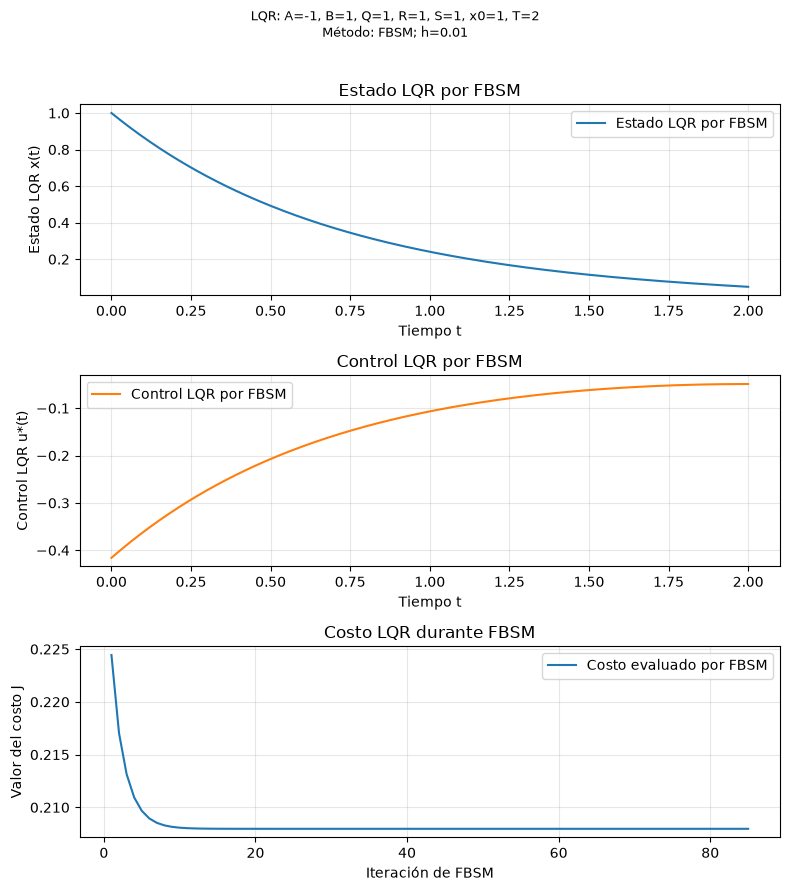

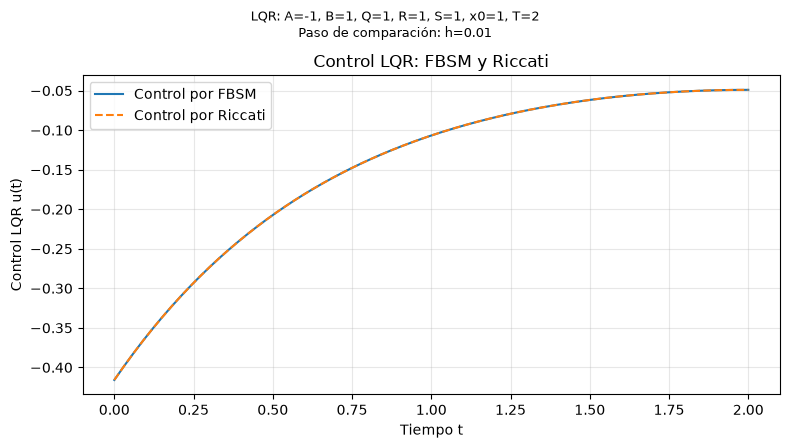

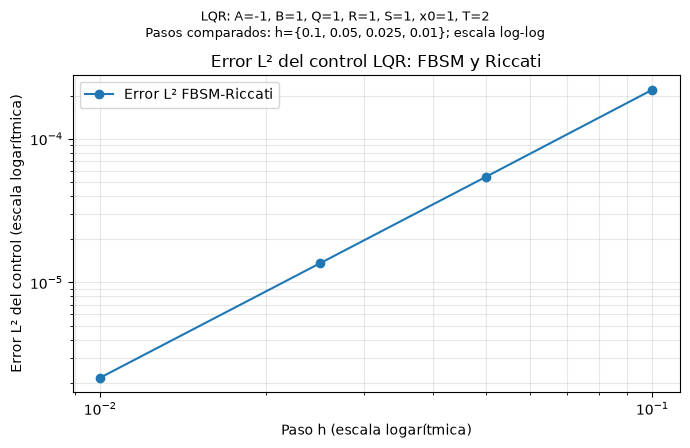

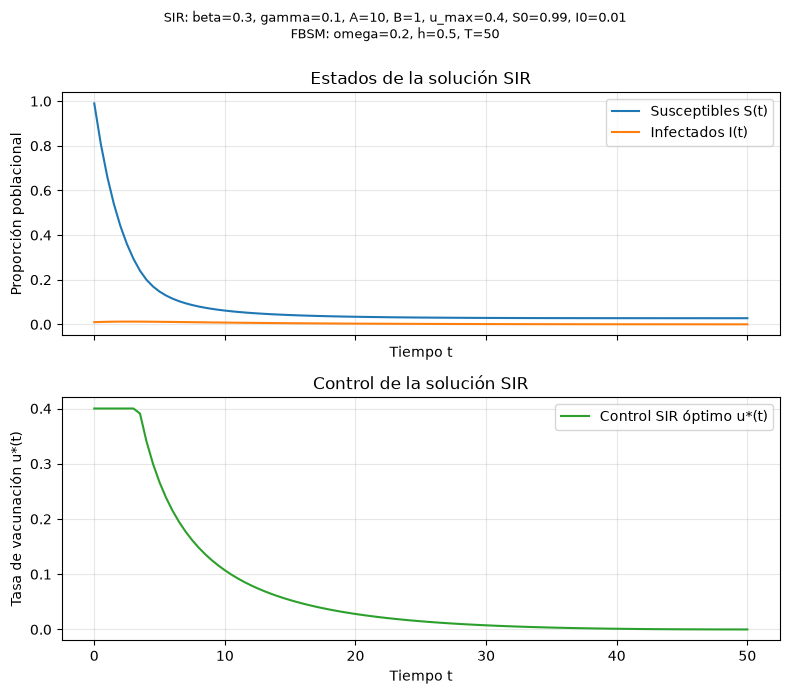

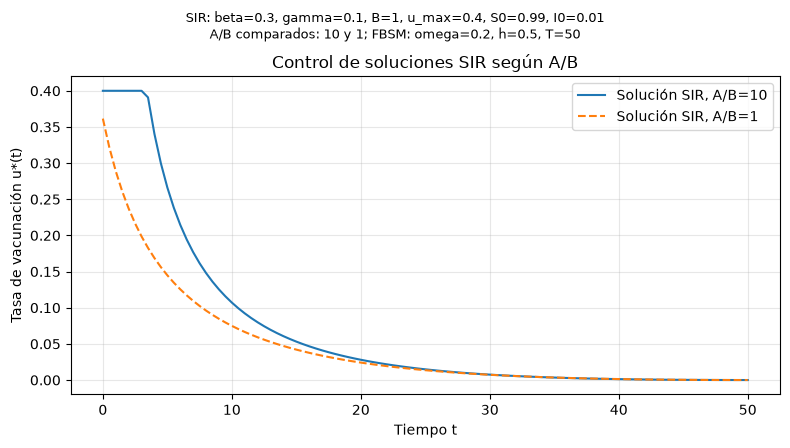

In [12]:
resumen_problema3 = generar_reporte_problema3(
    RUTA_PROBLEMA3,
    modo_rapido=MODO_RAPIDO,
)

print("Problema 3(a):", resumen_problema3["3a"])
print(
    "Problema 3(b), error L² para h=0.01:",
    f"{resumen_problema3['3b']['error_h_001']:.8e}",
)
print(
    "Problema 3(c), controles medios A/B=10 y A/B=1:",
    f"{resumen_problema3['3c']['control_medio_alto']:.6f}",
    f"{resumen_problema3['3c']['control_medio_bajo']:.6f}",
)

figuras_problema3 = resumen_problema3["figuras"]

if "ipykernel" in sys.modules:
    plt.show(block=False)
for figura in figuras_problema3:
    plt.close(figura)

# Problema 4: optimización directa

## Problema 4(a): métodos auxiliares

Se evalúan el gradiente por adjunto, la proyección, el paso de
Barzilai--Borwein y la búsqueda de línea de Armijo.

In [13]:
problema_lqr = crear_problema_lqr_fbsm(
    -1.0,  # a
    1.0,   # b
    1.0,   # q
    1.0,   # r
    1.0,   # s
    2.0,   # T
    1.0,   # x0
)

h_lqr = 0.05
metodo_lqr = "rk4"
nodos_lqr = int(round(2.0 / h_lqr)) + 1
u_1 = np.zeros((nodos_lqr, 1))
g_1 = problema_lqr.grad(u_1, metodo_lqr)
v_1 = problema_lqr.proj(u_1 - g_1, metodo_lqr) - u_1

u_2 = problema_lqr.proj(u_1 + 0.1 * v_1, metodo_lqr)
g_2 = problema_lqr.grad(u_2, metodo_lqr)
paso_bb = problema_lqr.BBStep(u_1, u_2, g_1, g_2, metodo_lqr)

control_prueba_caja = np.linspace(-1.0, 1.0, tiempos_control.size)[:, None]
proyeccion_caja = problema_caja.proj(control_prueba_caja, "crank_nicolson")

costo_inicial = problema_lqr.evaluar_costo(
    lambda t: np.zeros(1), h_lqr, metodo_lqr
)
paso_armijo = problema_lqr.backtracking(
    u_1,
    g_1,
    v_1,
    a=1e-4,
    b=0.5,
    J_hat=costo_inicial,
    metodo_integracion=metodo_lqr,
    t_inicial=paso_bb,
)

pd.DataFrame(
    [
        {"método auxiliar": "grad", "resultado": f"shape={g_1.shape}"},
        {
            "método auxiliar": "proj",
            "resultado": (
                f"mínimo={proyeccion_caja.min():.2f}, "
                f"máximo={proyeccion_caja.max():.2f}"
            ),
        },
        {"método auxiliar": "BBStep", "resultado": f"{paso_bb:.6e}"},
        {"método auxiliar": "backtracking", "resultado": f"{paso_armijo:.6e}"},
    ]
)

,método auxiliar,resultado
0,grad,"shape=(41, 1)"
1,proj,"mínimo=-0.50, máximo=0.50"
2,BBStep,6.287272e-01
3,backtracking,6.287272e-01


## Problema 4(b): método de gradiente proyectado

In [14]:
resultado_gradiente = problema_lqr.gradiente_proyectado(
    u_inicial=u_1,
    max_iter=100,
    tolerancia=1e-5,
    metodo_integracion=metodo_lqr,
)

print("Convergió:", resultado_gradiente.convergio)
print("Iteraciones:", resultado_gradiente.iteraciones)
print("Forma del control:", resultado_gradiente.control.shape)
print("Forma de los estados:", resultado_gradiente.estados.shape)
print("Forma de los adjuntos:", resultado_gradiente.adjuntos.shape)
print("Costo final:", resultado_gradiente.historial_costos[-1])

Convergió: True
Iteraciones: 4
Forma del control: (41, 1)
Forma de los estados: (41, 1)
Forma de los adjuntos: (41, 1)
Costo final: 0.20795550107054886


## Problema 4c: comparación entre FBSM y gradiente proyectado

Se comparan los resultados de FBSM y gradiente proyectado para los
problemas LQR y SIR. Se presentan el costo, el residuo de
estacionariedad y el número de iteraciones.

<!-- not evidence of global optimality -->

Comparación LQR


,case,method,common_final_cost,riccati_l2_error,relative_cost_gap,stationarity_residual,converged,native_iterations,native_history_label,runtime_seconds
0,LQR,FBSM,0.208273,0.000052,2.512717e-07,0.000002,True,44,FBSM accepted control k=1..44,2.410000
1,LQR,Projected gradient,0.208274,0.000792,3.979415e-06,0.000898,True,4,Projected gradient initial control k=0; accept...,0.235624


Comparación SIR


,a_over_b,method,common_final_cost,stationarity_residual,converged,native_iterations,native_history_label,runtime_seconds,optimality_disclaimer
0,1.0,FBSM,0.477785,0.000002,True,51,FBSM accepted control k=1..51,13.356256,First-order proxy only; not evidence of global...
1,1.0,Projected gradient,0.477786,0.000577,True,18,Projected gradient initial control k=0; accept...,1.968918,First-order proxy only; not evidence of global...
2,10.0,FBSM,2.422644,0.000003,True,58,FBSM accepted control k=1..58,16.964767,First-order proxy only; not evidence of global...
3,10.0,Projected gradient,2.422643,0.000082,True,14,Projected gradient initial control k=0; accept...,1.188240,First-order proxy only; not evidence of global...


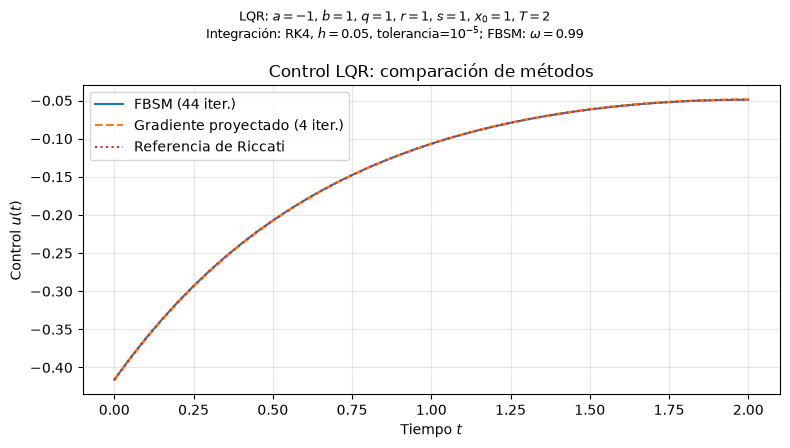

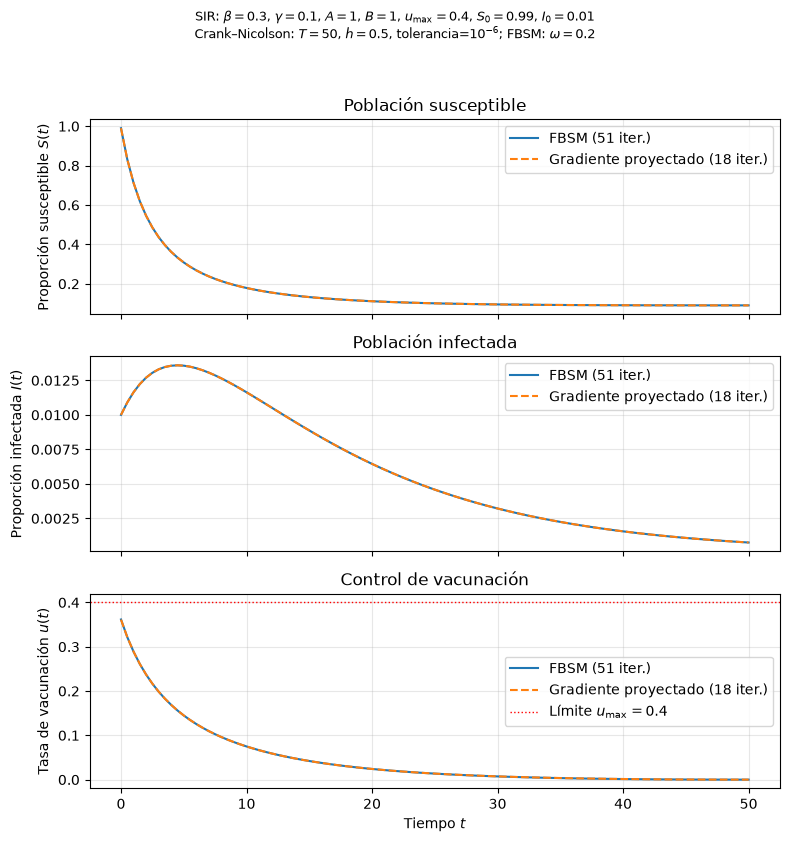

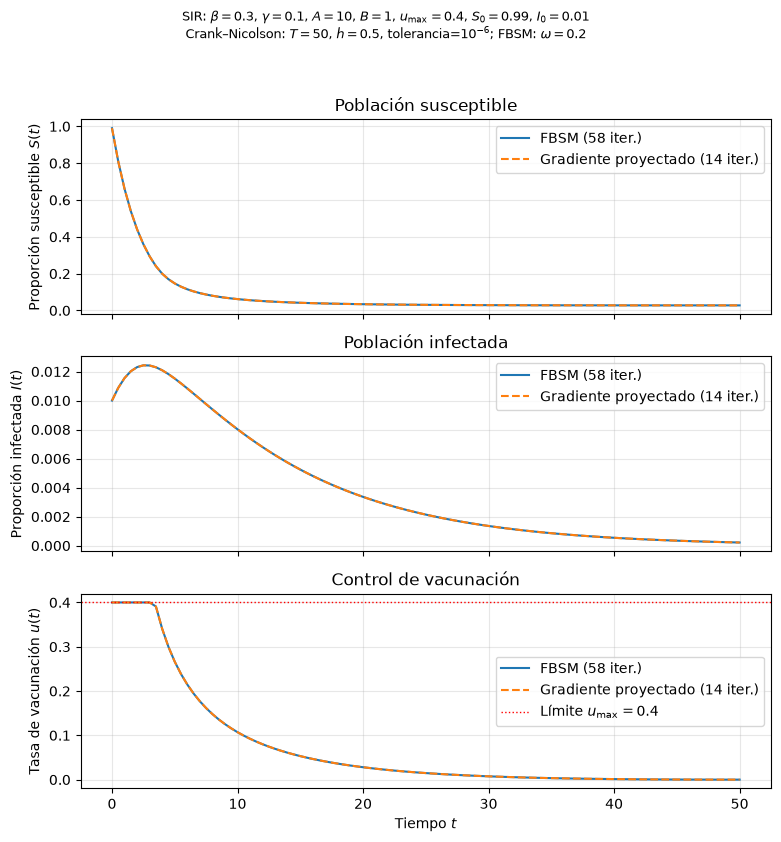

In [15]:
MODO_RAPIDO_PROBLEMA4 = False

resultado_problema4 = generar_reporte_problema4(
    RUTA_PROBLEMA4,
    modo_rapido=MODO_RAPIDO_PROBLEMA4,
)

tabla_lqr = resultado_problema4.tabla_lqr
tabla_sir = resultado_problema4.tabla_sir

print("Comparación para el problema LQR:")
print(tabla_lqr.to_string(index=False))

print("\nComparación para el problema SIR:")
print(tabla_sir.to_string(index=False))

figuras_problema4 = resultado_problema4.figuras

if "ipykernel" in sys.modules:
    plt.show(block=False)
for figura in figuras_problema4:
    plt.close(figura)

## Archivos generados

In [16]:
for ruta in (
    RUTA_LOTKA,
    RUTA_VDP,
    RUTA_PROBLEMA3,
    RUTA_PROBLEMA4,
):
    print(f"\n{ruta.relative_to(RAIZ_REPOSITORIO)}")
    for archivo in sorted(ruta.iterdir()):
        print(" -", archivo.name)


tarea1/resultados_graficos/1_lotka_volterra
 - diagrama_fase.png
 - error_vs_h.png
 - series_temporales.png

tarea1/resultados_graficos/1_van_der_pol
 - diagrama_fase_mu_0_1.png
 - diagrama_fase_mu_1000.png
 - error_vs_h_mu_0_1.png
 - error_vs_h_mu_1000_explicitos_pasos_grandes.png
 - error_vs_h_mu_1000_explicitos_pasos_pequenos.png
 - error_vs_h_mu_1000_implicitos_pasos_grandes.png

tarea1/resultados_graficos/3_fbsm
 - .gitkeep
 - 3a_fbsm_trayectorias.png
 - 3b_error_l2_vs_h.png
 - 3b_fbsm_vs_riccati.png
 - 3c_sir_comparacion_ab.png
 - 3c_sir_trayectorias.png

tarea1/resultados_graficos/4_gradiente_proyectado
 - .gitkeep
 - lqr_comparison.csv
 - lqr_comparison.png
 - lqr_comparison.tex
 - sir_a_over_b_1.png
 - sir_a_over_b_10.png
 - sir_comparison.csv
 - sir_comparison.tex
